In [42]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import os
import re
from collections import defaultdict

# Utility functions

In [43]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)

    results = {}
    answer_prefix="Answer Choice "
    
    import re

    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("\n")
        pattern = search_substring

        for line in lines:
            # Use regex to find the pattern
            match = re.search(pattern, line)
            if match:
                # Return everything after the pattern, stripped of whitespace
                return line[match.end():].strip()

        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results

In [44]:
def extract_shots(experiment_files):
    """
    Extracts the shots values from a list of file paths, accounting for various patterns.
    
    Args:
        experiment_files (list): List of file paths containing shots information.
    
    Returns:
        list: Sorted list of unique shots values.
    """
    shots = set()  # Use a set to ensure uniqueness
    for file in experiment_files:
        # Extract the numeric patterns with flexible position
        match = re.search(r"(/d+)_(/d+)_(/d+)_(/d+)", file)
        if match:
            # Convert matched groups to integers
            numbers = [int(x) for x in match.groups()]
            # Sort numbers to extract the second largest
            numbers.sort()
            if len(numbers) > 1:
                shots.add(numbers[-2])
            else:
                shots.add(0)

    return sorted(shots)

In [45]:
def extract_numbers_from_filenames(directory):
    categories = defaultdict(list)
    pattern = r"chexpert_(/d+)_(/d+)_(/d+)_(/d+).*/.pkl"


    for root, _, files in os.walk(directory):
        for file in files:
            match = re.search(pattern, file)
            if match:
                numbers = tuple(map(int, match.groups()))  # Convert to integers for proper comparison
                # Classify based on criteria
                if numbers[2:] == (0, 0):
                    categories['male'].append(numbers)
                    if numbers[:2] == (0, 0):
                        categories['both'].append(numbers)
                elif numbers[:2] == (0, 0):
                    categories['female'].append(numbers)
                elif numbers[:2] == numbers[2:]:
                    categories['both'].append(numbers)

    # Sort each category and join the tuples back into strings
    for key in categories:
        categories[key] = ["_".join(map(str, numbers)) for numbers in sorted(categories[key])]

    return categories

In [ ]:
def res_to_vec(res):
    test_df = pd.read_csv("C:/Users/sonne/Documents/Github/biasICL/chexpert_SexBinary_PTX_final_demo_df.csv", index_col=0)
    num_errors = 0
    labels, preds, sex_list = [], [], []
    for i in test_df.itertuples():
        sex = 'F' if i.Sex == 'Female' else 'M'
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "B" if i.Pneumothorax == False else "A"
        labels.append(ground_truth)
        preds.append(pred_text)
        sex_list.append(sex)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    return labels,preds,sex_list

In [47]:
def calculate_avg_prediction(labels, preds):
    # Convert 'A' to 0 and 'B' to 1
    label_map = {'A': 0, 'B': 1}
    
    # Map the labels and predictions to numeric values
    numeric_preds = [label_map[p] for p in preds]
    numeric_labels = [label_map[l] for l in labels]
    
    # Calculate the average of the predictions and labels
    avg_preds = np.mean(numeric_preds)
    avg_labels = np.mean(numeric_labels)
    
    return avg_preds, avg_labels


In [48]:
def calculate_metrics_across_replicates(exp_lists):
    """
    Calculate metrics across technical replicates
    
    Parameters:
    exp_lists: List of 3 lists, where each inner list contains experiments for one technical replicate
               Corresponding experiments should be in the same order in each replicate list
    
    Returns:
    Dictionaries containing means and standard errors for bulk, FST 1/2, and FST 5/6 metrics
    """
    # Initialize data structures for each metric type
    bulk_metrics = {'mean': [], 'stderr': []}
    fst12_metrics = {'mean': [], 'stderr': []}
    fst56_metrics = {'mean': [], 'stderr': []}
    
    # Get number of experiments in each replicate
    n_experiments = len(exp_lists[0])
    
    # For each experiment position
    for exp_idx in range(n_experiments):
        # Storage for metrics from each replicate
        bulk_replicate_metrics = []
        fst12_replicate_metrics = []
        fst56_replicate_metrics = []
        
        # Process each replicate
        for replicate_list in exp_lists:
            exp = replicate_list[exp_idx]
            results = pickle_to_res(exp)
            print(results)
            print(exp)
            labels, preds, race = res_to_vec(results)
            
            # Calculate bulk metrics
            accuracy, tpr, tnr, fscore = calculate_metrics(labels, preds)
            avg_preds, avg_labels = calculate_avg_prediction(labels, preds)
            bulk_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_preds,
                'avg_labels': avg_labels
            })
            
            # Calculate FST 1/2 metrics
            fst12_labels, fst12_preds = filter_by_sex(labels, preds, race, 'F')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst12_labels, fst12_preds)
            avg_fst12_preds, avg_fst12_labels = calculate_avg_prediction(fst12_labels, fst12_preds)
            fst12_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_fst12_preds,
                'avg_labels': avg_fst12_labels
            })
            
            # Calculate FST 5/6 metrics
            fst56_labels, fst56_preds = filter_by_sex(labels, preds, race, 'M')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst56_labels, fst56_preds)
            avg_fst56_preds, avg_fst56_labels = calculate_avg_prediction(fst56_labels, fst56_preds)
            fst56_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_fst56_preds,
                'avg_labels': avg_fst56_labels
            })
        
        # Calculate means and standard errors across replicates
        def calc_mean_stderr(replicate_data, metric):
            values = [rep[metric] for rep in replicate_data]
            return np.mean(values), np.std(values) / np.sqrt(len(values))
        
        # Process bulk metrics
        bulk_means = {}
        bulk_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(bulk_replicate_metrics, metric)
            bulk_means[metric] = mean
            bulk_stderrs[metric] = stderr
        bulk_metrics['mean'].append(bulk_means)
        bulk_metrics['stderr'].append(bulk_stderrs)
        
        # Process FST 1/2 metrics
        fst12_means = {}
        fst12_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(fst12_replicate_metrics, metric)
            fst12_means[metric] = mean
            fst12_stderrs[metric] = stderr
        fst12_metrics['mean'].append(fst12_means)
        fst12_metrics['stderr'].append(fst12_stderrs)
        
        # Process FST 5/6 metrics
        fst56_means = {}
        fst56_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(fst56_replicate_metrics, metric)
            fst56_means[metric] = mean
            fst56_stderrs[metric] = stderr
        fst56_metrics['mean'].append(fst56_means)
        fst56_metrics['stderr'].append(fst56_stderrs)
    
    return bulk_metrics, fst12_metrics, fst56_metrics

def calculate_metrics(actual, predicted):
    TP = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    TN = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    FP = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    FN = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual) if len(actual) > 0 else 0
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_sex(actual, predicted, sex, sex_value):
    filtered_actual = [a for a, s in zip(actual, sex) if s == sex_value]
    filtered_predicted = [p for p, s in zip(predicted, sex) if s == sex_value]
    return filtered_actual, filtered_predicted


In [49]:
def plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, title, use_error_bars=False):
    """
    Plot all experiment metrics (accuracy, TPR, F-score) in a single figure with multiple rows
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations/errors
    shots: list of integers representing the number of shots for each experiment
    title: string for the overall figure title
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(12, 9))
    
    # Create gridspec with adjusted spacing
    gs = fig.add_gridspec(2, 2, 
                         height_ratios=[1, 1], 
                         top=0.85,      # Space for title
                         bottom=0.1,    # Space for bottom labels
                         left=0.1,      # Space for left labels
                         right=0.9,     # Space for right margin
                         hspace=0.25,   # Increased vertical space between subplots
                         wspace=0.20)   # Space between columns
    
    axes = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(fig.add_subplot(gs[i, j]))
        axes.append(row)
    axes = np.array(axes)
    
    # Add title with pachexpertng
    fig.suptitle(title, fontsize=16, y=0.93)
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    metrics = ['accuracy', 'fscore']
    
    for idx, score_type in enumerate(metrics):
        # Extract means and standard deviations for current metric
        bulk_means = [m[score_type] for m in bulk_metrics['mean']]
        bulk_stds = [s[score_type] for s in bulk_metrics['stderr']]
        
        fst12_means = [m[score_type] for m in fst12_metrics['mean']]
        fst12_stds = [s[score_type] for s in fst12_metrics['stderr']]
        
        fst56_means = [m[score_type] for m in fst56_metrics['mean']]
        fst56_stds = [s[score_type] for s in fst56_metrics['stderr']]
        
        # Left plot (metrics)
        if use_error_bars:
            axes[idx, 0].errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                                color=line_colors[0], label=f'Aggregate {score_type}', 
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                                color=line_colors[1], label=f'Female {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                                color=line_colors[2], label=f'Male {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 0].plot(shots, bulk_means, 'o-', color=line_colors[0], 
                            label=f'Aggregate {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots, 
                                    np.array(bulk_means) - np.array(bulk_stds),
                                    np.array(bulk_means) + np.array(bulk_stds),
                                    color=line_colors[0], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst12_means, 's-', color=line_colors[1], 
                            label=f'Female {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst12_means) - np.array(fst12_stds),
                                    np.array(fst12_means) + np.array(fst12_stds),
                                    color=line_colors[1], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst56_means, '^-', color=line_colors[2], 
                            label=f'Male {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst56_means) - np.array(fst56_stds),
                                    np.array(fst56_means) + np.array(fst56_stds),
                                    color=line_colors[2], alpha=0.2)
        
        axes[idx, 0].set_xlabel('Number of Shots')
        axes[idx, 0].set_ylabel(score_type.upper())
        axes[idx, 0].set_title(f'{score_type.upper()} by Number of Shots and sex')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, linestyle='--', alpha=0.7)
        
        # Right plot (bias)
        biases_mean = np.array(fst12_means) - np.array(fst56_means)
        biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
        
        if use_error_bars:
            axes[idx, 1].errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                                color='purple', label=f'Bias (Female - Male {score_type})',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 1].plot(shots, biases_mean, 'o-', color='purple', 
                            label=f'Bias (Female - Male {score_type})', linewidth=2)
            axes[idx, 1].fill_between(shots,
                                    biases_mean - biases_std,
                                    biases_mean + biases_std,
                                    color='purple', alpha=0.2)
        
        axes[idx, 1].set_xlabel('Number of Shots')
        axes[idx, 1].set_ylabel('Bias')
        axes[idx, 1].set_title(f'Bias in {score_type.upper()} by Number of Shots')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

# Male only

In [50]:
# Parameters for customization
base_path = "C:/Users/sonne/Downloads"
rep_folders = ["baseRate0130"]  # Subfolders for each replicate
model_name = "Gemini1.5"  # Model name
numbers = extract_numbers_from_filenames(base_path + "/" + rep_folders[0]) # List of numerical settings
print(numbers)
# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/chexpert_{num}_{model_name}_50.pkl" for num in numbers["male"]]
    for folder in rep_folders
]

# Unpacking individual lists for convenience (optional)
print(exps_list)


defaultdict(<class 'list'>, {})
[[]]


In [51]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In [52]:
print((bulk_metrics), (fst12_metrics), (fst56_metrics))

{'mean': [], 'stderr': []} {'mean': [], 'stderr': []} {'mean': [], 'stderr': []}


[]


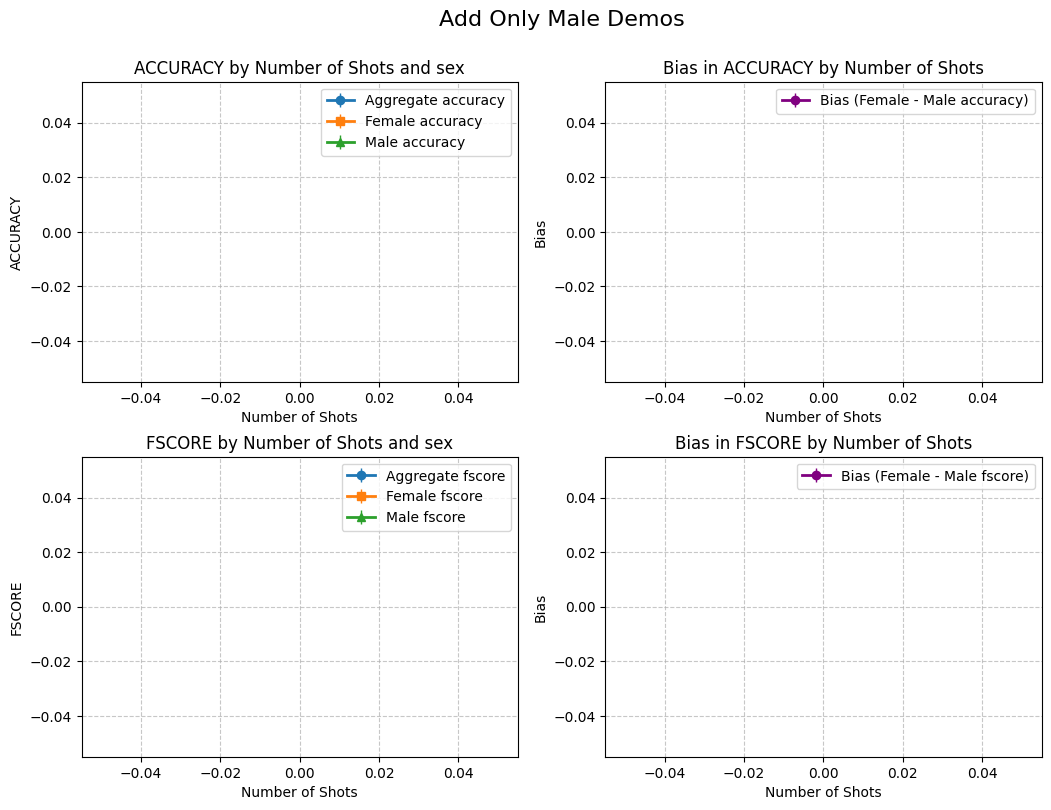

In [53]:
# Plot with confidence intervals
shots = extract_shots(numbers["male"])
print(shots)
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only Male Demos", 
                          use_error_bars=True)

# Female only 

In [54]:
# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers["fst12"]]
    for folder in rep_folders
]

In [55]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

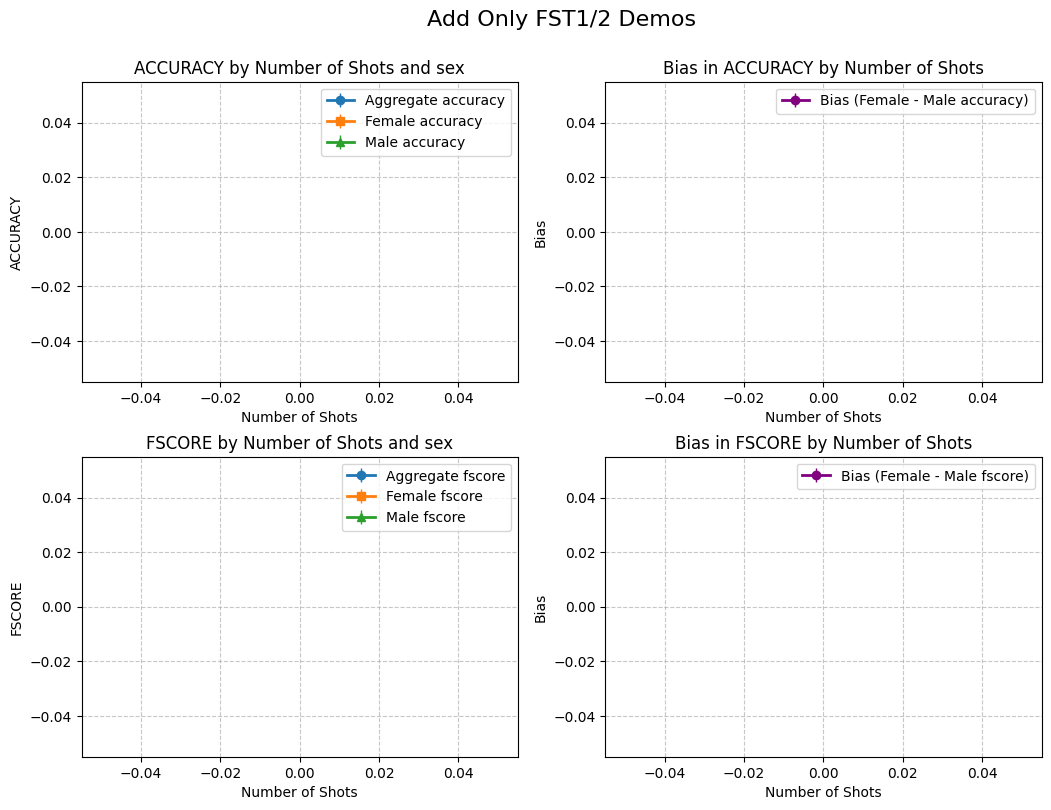

In [56]:
# Plot with confidence intervals
shots = extract_shots(numbers["fst12"])
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST1/2 Demos", 
                          use_error_bars=True)

# both fst12 and fst56

In [57]:
print(numbers)

defaultdict(<class 'list'>, {'male': [], 'fst12': []})


In [58]:
# Generate the experiment lists dynamically
# numbers = ["0_0", "10_10", "20_20", "30_30", "40_40", "50_50", "60_60", "70_70", "80_80", "90_90"]
numbers = ["0_300_300_0", "10_290_290_10", "20_280_280_20", "30_270_270_30", "40_260_260_40", "50_250_250_50", "60_240_240_60", "70_230_230_70", "80_220_220_80", "90_210_210_90", "100_200_200_100"]
exps_list = [
    [f"{base_path}/{folder}/chexpert_{num}_{model_name}_50.pkl" for num in numbers]
    for folder in rep_folders
]

In [59]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

{450: 'A', 257: 'A', 574: 'A', 202: 'A', 599: 'A', 397: 'A', 372: 'A', 413: 'A', 562: 'A', 80: 'A', 230: 'A', 66: 'A', 595: 'A', 256: 'A', 435: 'A', 265: 'A', 281: 'A', 591: 'A', 578: 'A', 487: 'A', 340: 'A', 559: 'A', 373: 'A', 530: 'A', 469: 'A', 514: 'A', 176: 'A', 527: 'A', 6: 'A', 111: 'A', 345: 'A', 461: 'A', 7: 'A', 404: 'A', 41: 'A', 305: 'A', 219: 'A', 17: 'A', 342: 'A', 164: 'A', 571: 'A', 9: 'A', 473: 'A', 231: 'A', 154: 'A', 597: 'A', 364: 'A', 133: 'A', 393: 'A', 583: 'A', 352: 'A', 358: 'A', 249: 'A', 377: 'B', 191: 'A', 526: 'B', 343: 'A', 406: 'A', 412: 'A', 73: 'A', 213: 'A', 499: 'A', 522: 'A', 104: 'A', 14: 'A', 318: 'A', 472: 'A', 145: 'A', 453: 'A', 294: 'A', 309: 'A', 170: 'A', 192: 'A', 263: 'A', 248: 'A', 416: 'A', 560: 'A', 216: 'A', 573: 'A', 35: 'A', 261: 'A', 349: 'A', 159: 'A', 10: 'A', 253: 'A', 589: 'A', 523: 'A', 70: 'A', 254: 'A', 178: 'A', 353: 'A', 536: 'A', 172: 'A', 590: 'A', 437: 'A', 541: 'A', 459: 'A', 307: 'A', 394: 'A', 444: 'A', 501: 'A', 234:

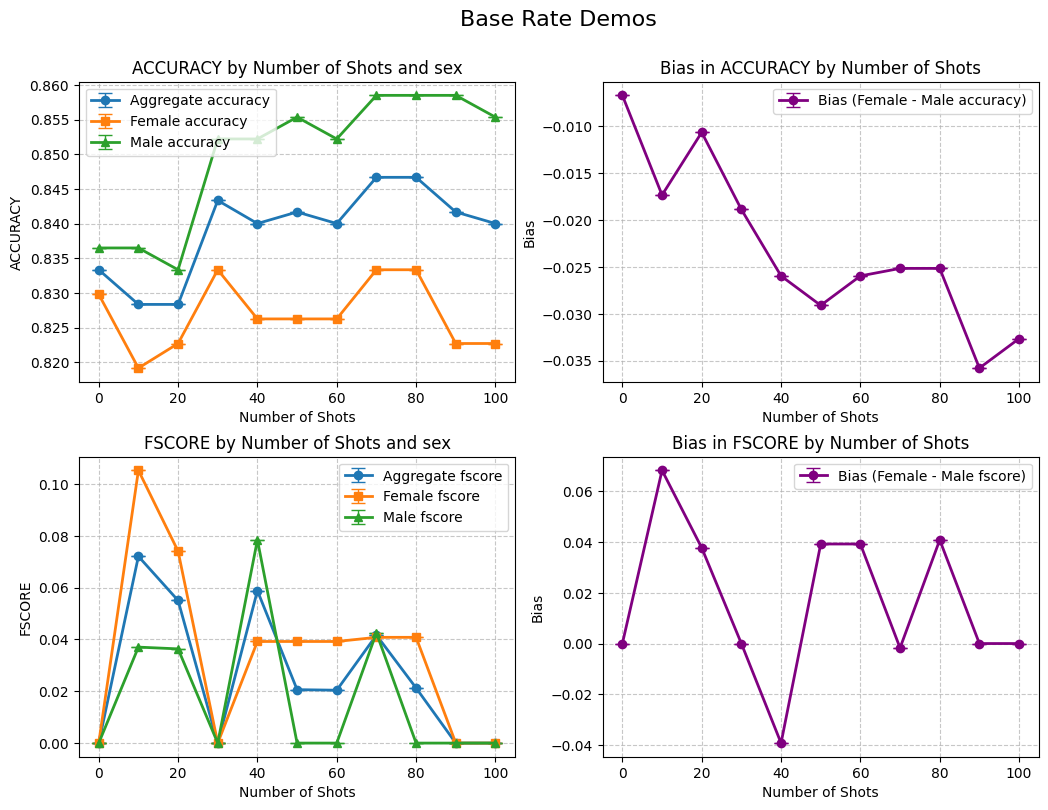

In [63]:
# Plot with confidence intervals
shots = list(range(0, 110, 10))
# shots = numbers
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Base Rate Demos", 
                          use_error_bars=True)

In [61]:
print(bulk_metrics, fst12_metrics, fst56_metrics)

{'mean': [{'accuracy': np.float64(0.8333333333333334), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0), 'avg_preds': np.float64(0.021666666666666667), 'avg_labels': np.float64(0.145)}, {'accuracy': np.float64(0.8283333333333334), 'tpr': np.float64(0.04597701149425287), 'fscore': np.float64(0.07207207207207207), 'avg_preds': np.float64(0.04), 'avg_labels': np.float64(0.145)}, {'accuracy': np.float64(0.8283333333333334), 'tpr': np.float64(0.034482758620689655), 'fscore': np.float64(0.05504587155963302), 'avg_preds': np.float64(0.03666666666666667), 'avg_labels': np.float64(0.145)}, {'accuracy': np.float64(0.8433333333333334), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0), 'avg_preds': np.float64(0.011666666666666667), 'avg_labels': np.float64(0.145)}, {'accuracy': np.float64(0.84), 'tpr': np.float64(0.034482758620689655), 'fscore': np.float64(0.0588235294117647), 'avg_preds': np.float64(0.025), 'avg_labels': np.float64(0.145)}, {'accuracy': np.float64(0.8416666666666667), 'tpr': np